<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Customer Segmentation Using Clustering - Credit Card Data</b><p>By: Ahmed Sharaf</p></div>


<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Import Libraries</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10


<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Load Data</div>


In [2]:
df = pd.read_csv('CC GENERAL.csv')

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Inspect Data</div>


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (8950, 18)


In [4]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Check Data Quality</div>


In [7]:
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
missing_data    

,Column,Missing_Count,Missing_Percentage
MINIMUM_PAYMENTS,MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,CREDIT_LIMIT,1,0.01


In [8]:
print(f"Total rows: {len(df)}")
print(f"Columns with missing values: {len(missing_data)}")

Total rows: 8950
Columns with missing values: 2


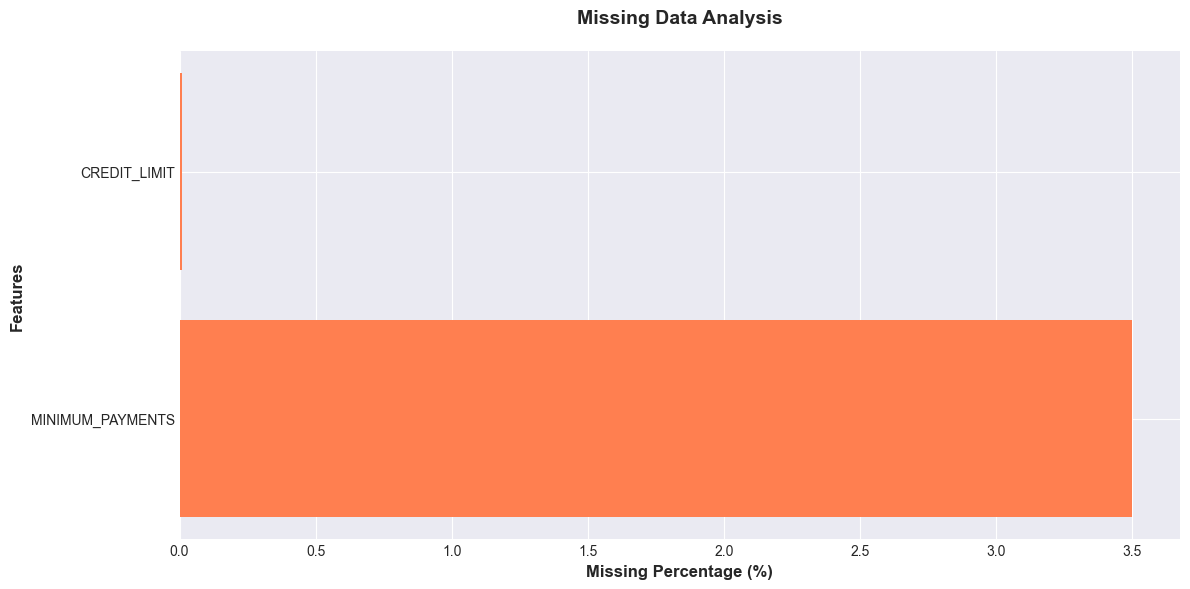

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(missing_data['Column'], missing_data['Missing_Percentage'], color='coral')
ax.set_xlabel('Missing Percentage (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Missing Data Analysis', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [11]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [12]:
duplicate_ids = df['CUST_ID'].duplicated().sum()
print(f"Number of duplicate customer IDs: {duplicate_ids}")

Number of duplicate customer IDs: 0


<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">EDA</div>


In [13]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical features: {len(numerical_features)}")
print(numerical_features)

Numerical features: 17
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


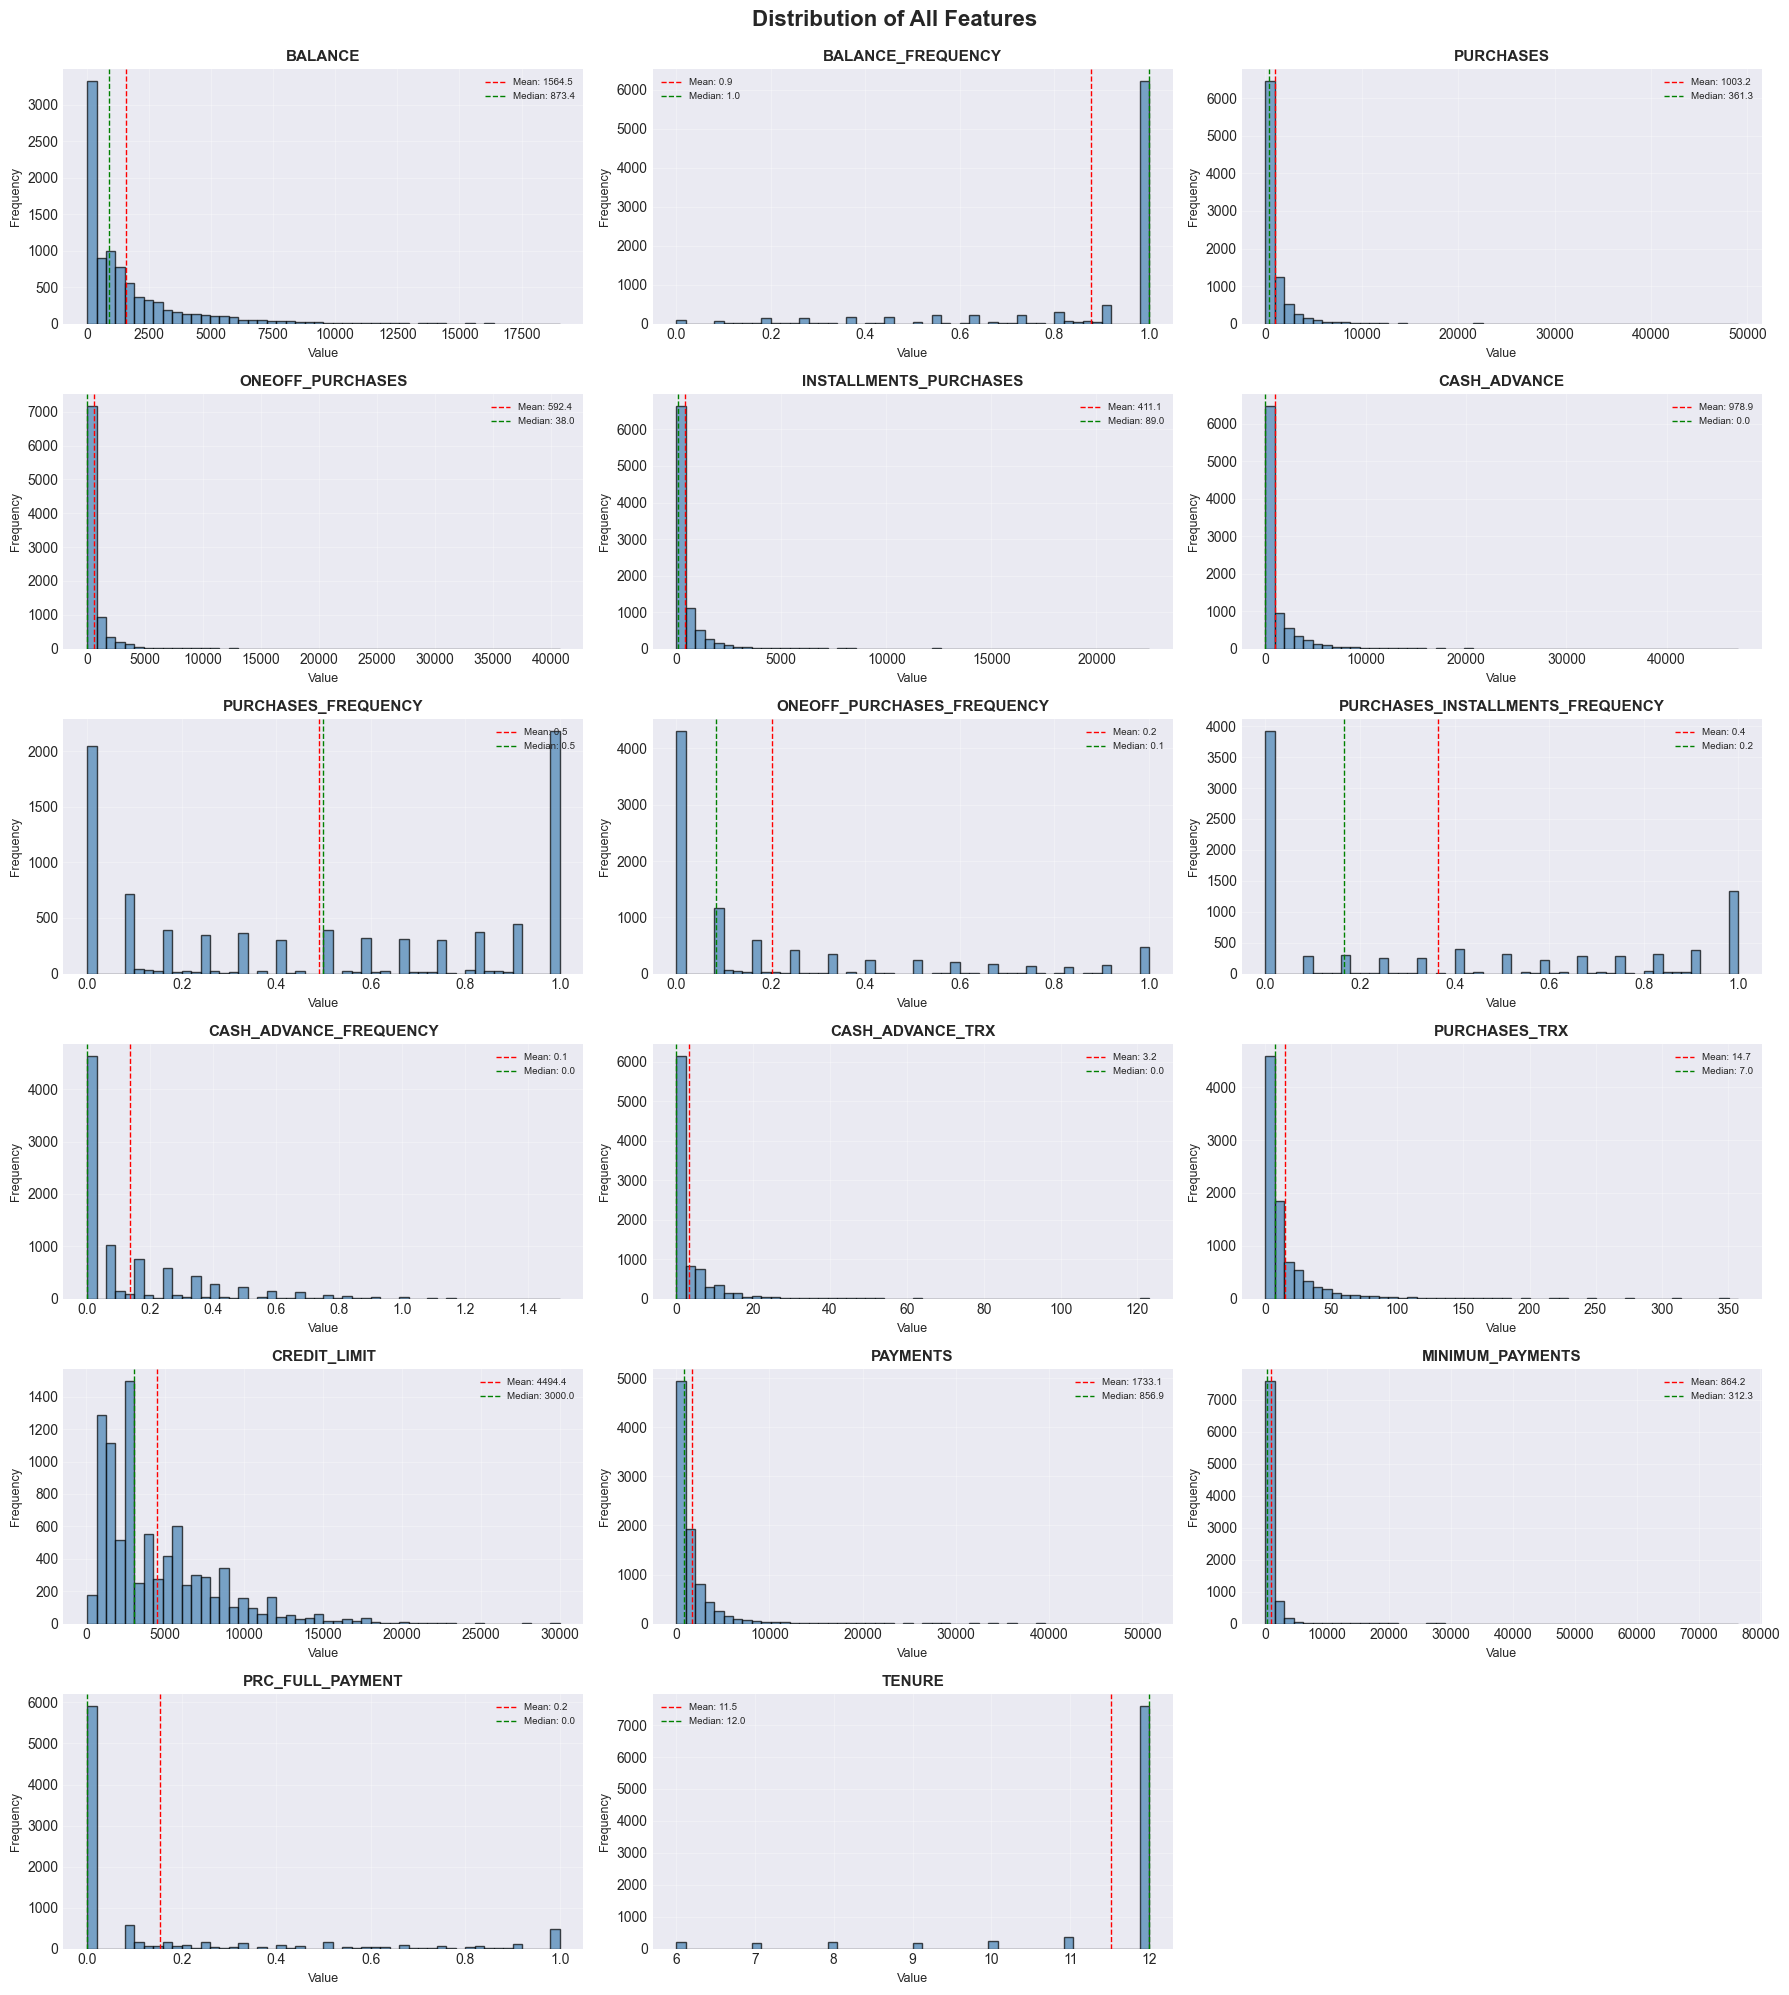

In [14]:
fig, axes = plt.subplots(6, 3, figsize=(18, 20))
fig.suptitle('Distribution of All Features', fontsize=16, fontweight='bold', y=0.995)

for idx, feature in enumerate(numerical_features):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    ax.hist(df[feature].dropna(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.grid(alpha=0.3)
    
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=1, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=1, label=f'Median: {median_val:.1f}')
    ax.legend(fontsize=7)

for idx in range(len(numerical_features), 18):
    row = idx // 3
    col = idx % 3
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()

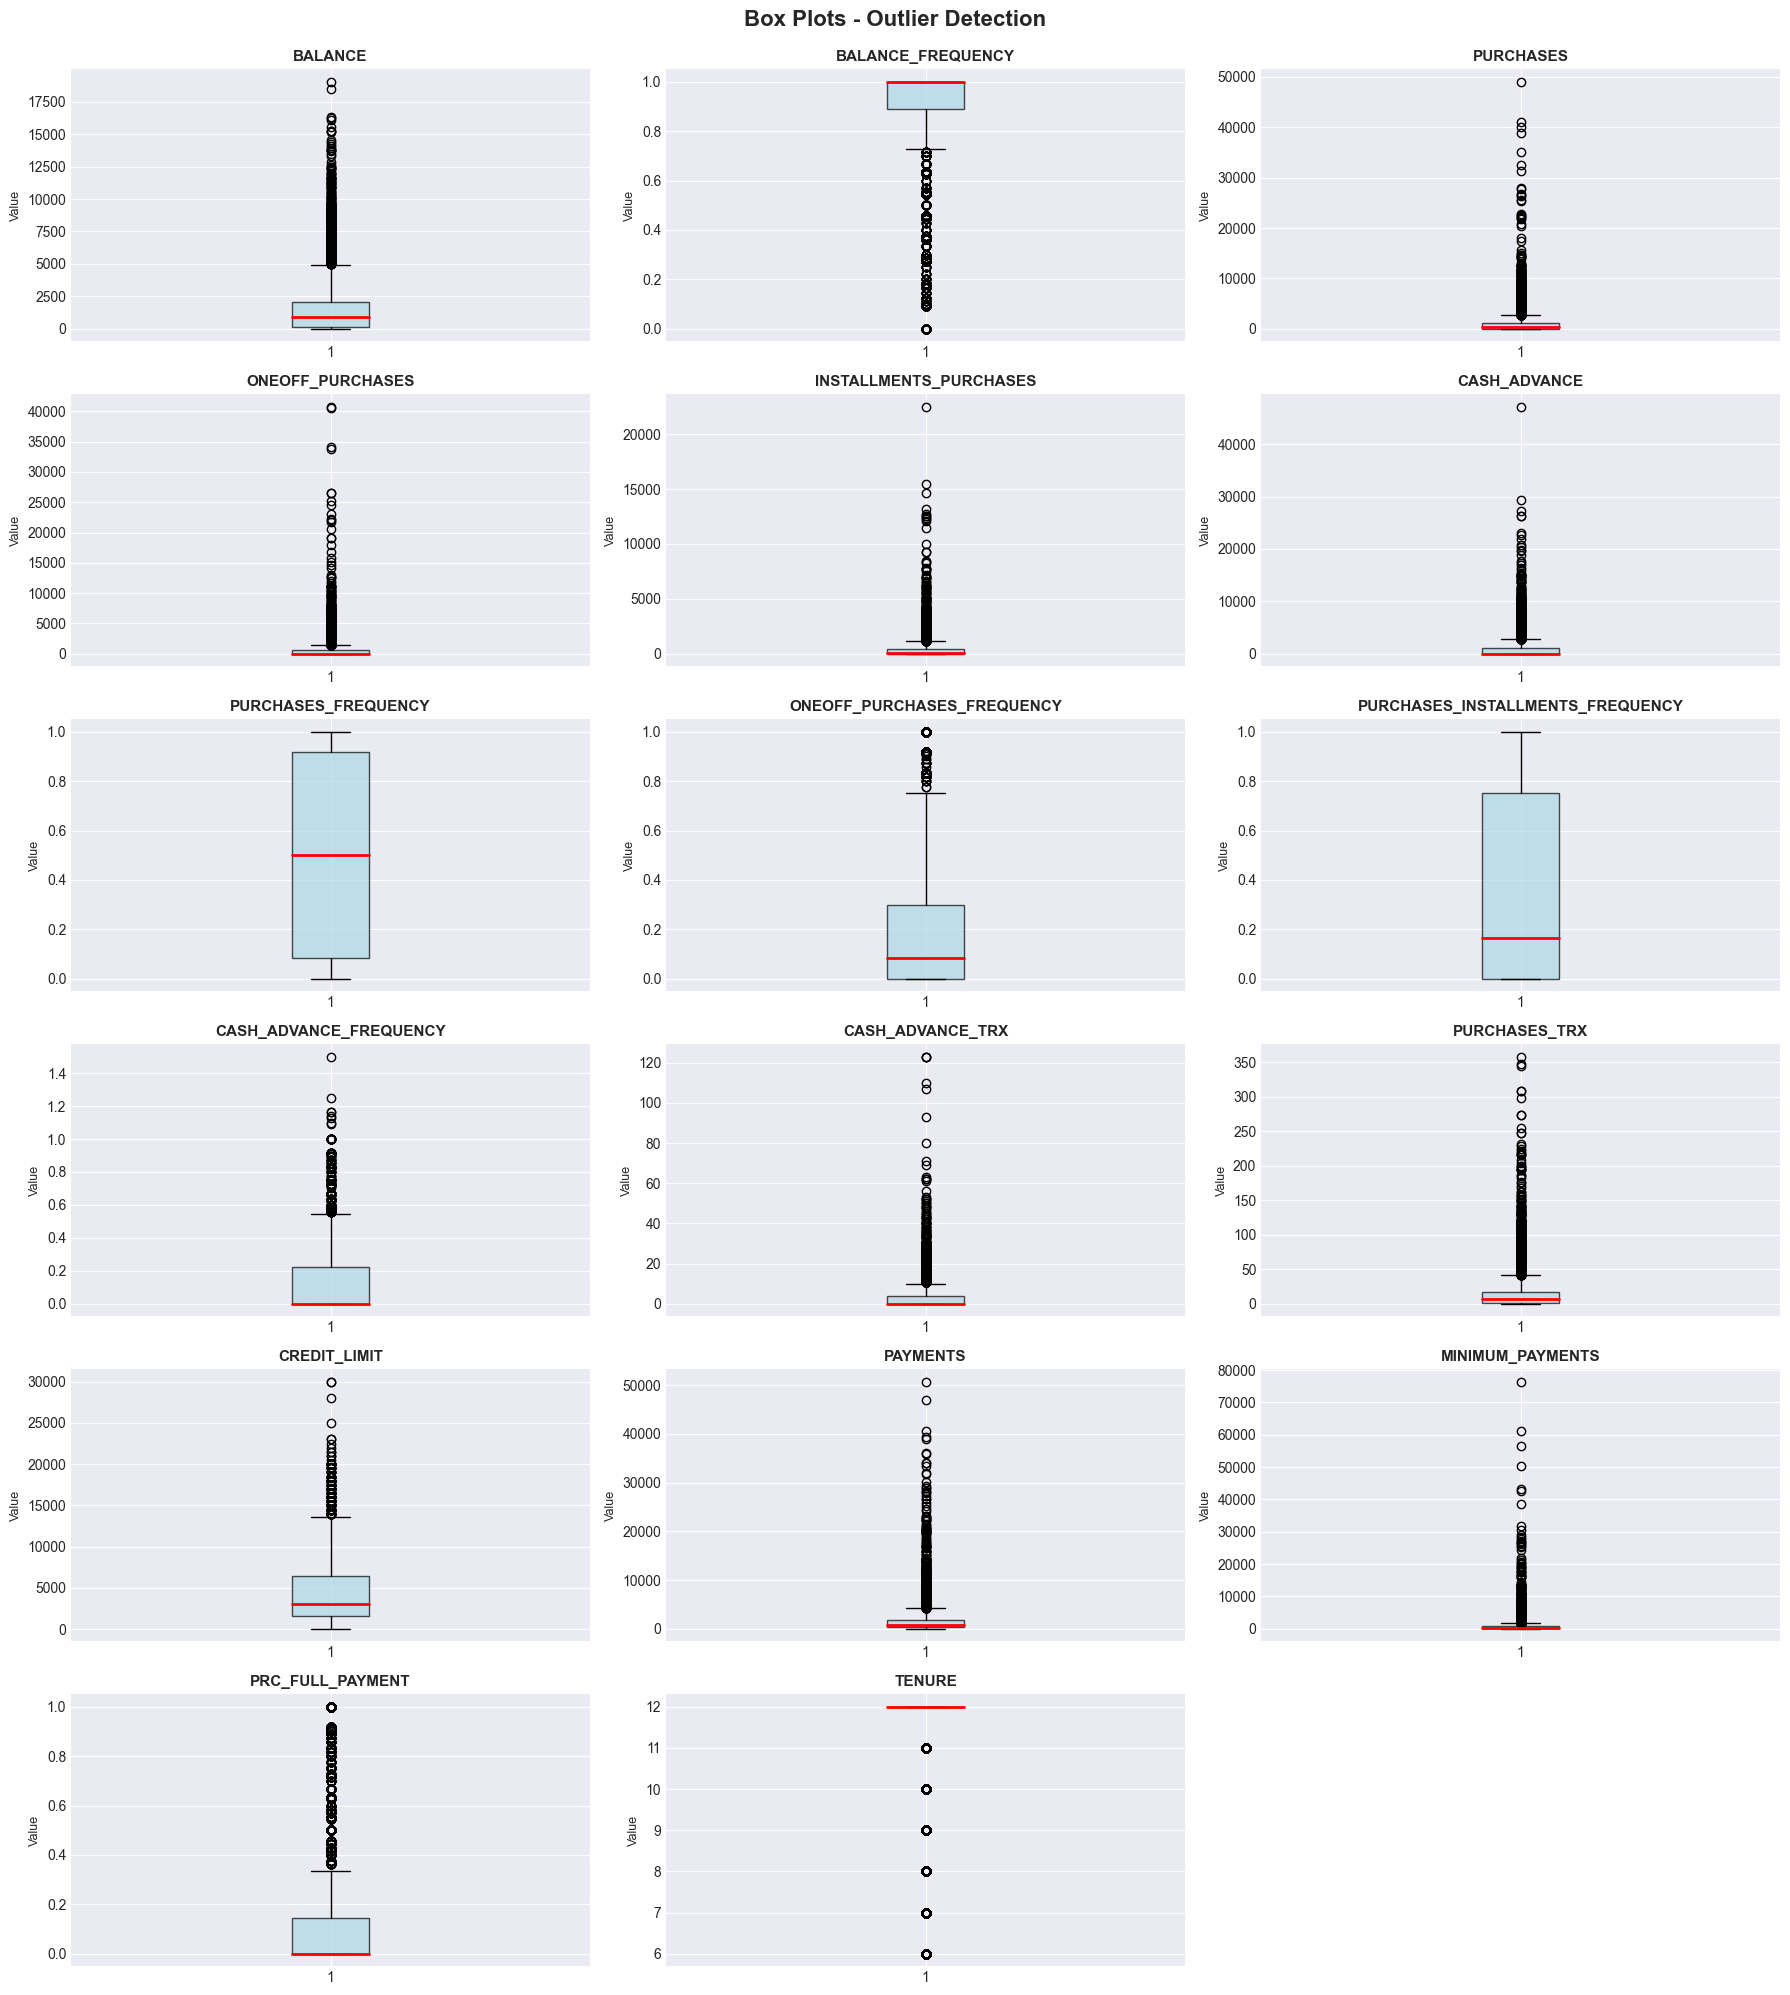

In [15]:
fig, axes = plt.subplots(6, 3, figsize=(18, 20))
fig.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold', y=0.995)

for idx, feature in enumerate(numerical_features):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    bp = ax.boxplot(df[feature].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'))
    
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)

for idx in range(len(numerical_features), 18):
    row = idx // 3
    col = idx % 3
    fig.delaxes(axes[row, col])

plt.tight_layout()
plt.show()

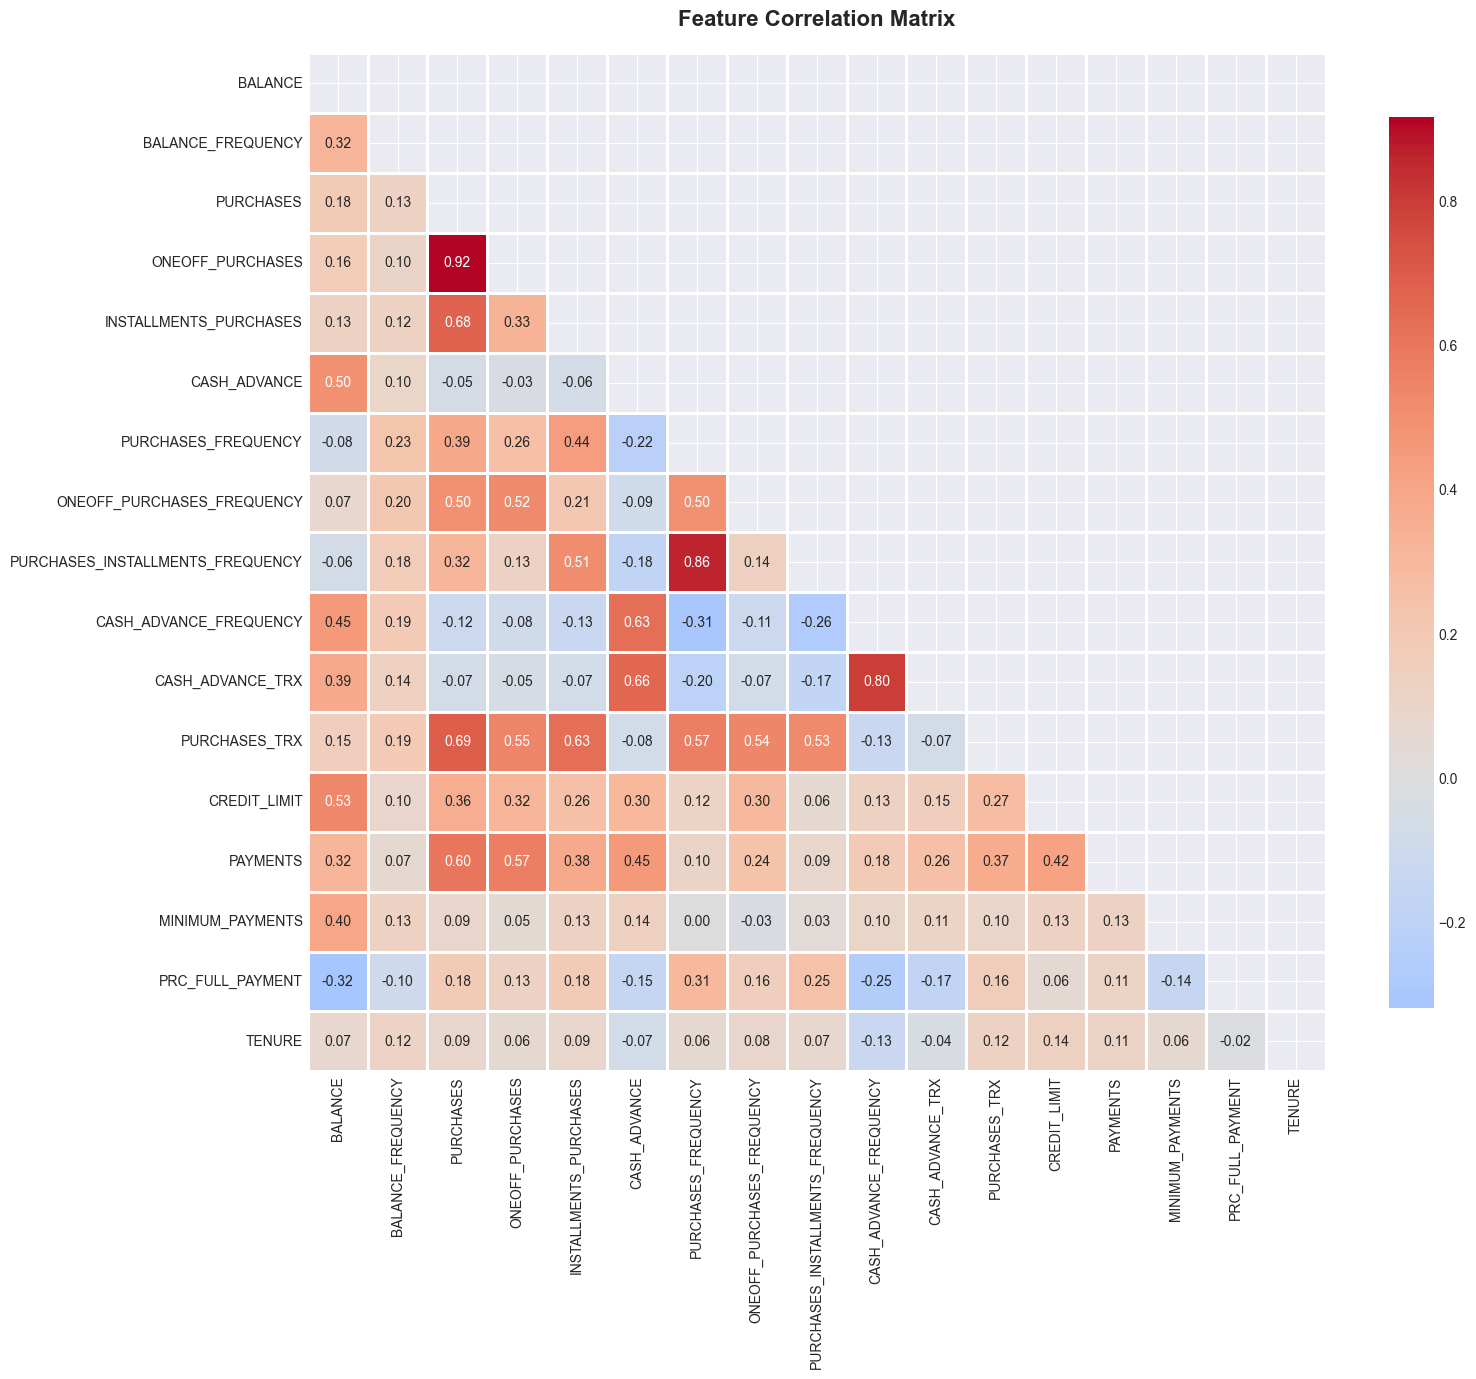

In [16]:
correlation_matrix = df[numerical_features].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [17]:
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print("Highly Correlated Feature Pairs (|correlation| > 0.7):")
print("="*80)
for pair in high_corr_pairs:
    print(f"{pair[0]:40s}  || {pair[1]:40s} : {pair[2]:.3f}")

Highly Correlated Feature Pairs (|correlation| > 0.7):
PURCHASES                                 || ONEOFF_PURCHASES                         : 0.917
PURCHASES_FREQUENCY                       || PURCHASES_INSTALLMENTS_FREQUENCY         : 0.863
CASH_ADVANCE_FREQUENCY                    || CASH_ADVANCE_TRX                         : 0.800


<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Data Preprocessing</div>


In [18]:
df_processed = df.copy()


In [19]:
df_processed = df_processed.drop('CUST_ID', axis=1)


In [20]:
imputer = SimpleImputer(strategy='median')
df_processed_imputed = pd.DataFrame(
    imputer.fit_transform(df_processed),
    columns=df_processed.columns
)

In [21]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_processed_imputed),
    columns=df_processed_imputed.columns
)

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">PCA</div>


In [22]:
pca_full = PCA()
pca_full.fit(df_scaled)

PCA()

In [23]:
pca = PCA(n_components=2, random_state=42)
data_pca = pca.fit_transform(df_scaled)

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">K Means</div>


In [24]:
K_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, labels))
    
    print(f"k={k}: Inertia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.3f}, ")



  File "c:\Users\ahmed\anaconda3\envs\py_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ahmed\anaconda3\envs\py_env\Lib\subprocess.py", line 546, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ahmed\anaconda3\envs\py_env\Lib\subprocess.py", line 1022, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\ahmed\anaconda3\envs\py_env\Lib\subprocess.py", line 1491, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


k=2: Inertia=127784.53, Silhouette=0.210, 
k=3: Inertia=111975.04, Silhouette=0.251, 
k=4: Inertia=99061.94, Silhouette=0.198, 
k=5: Inertia=91490.50, Silhouette=0.193, 
k=6: Inertia=84826.59, Silhouette=0.203, 
k=7: Inertia=79856.16, Silhouette=0.208, 
k=8: Inertia=74484.88, Silhouette=0.222, 
k=9: Inertia=69828.70, Silhouette=0.226, 
k=10: Inertia=66466.41, Silhouette=0.220, 


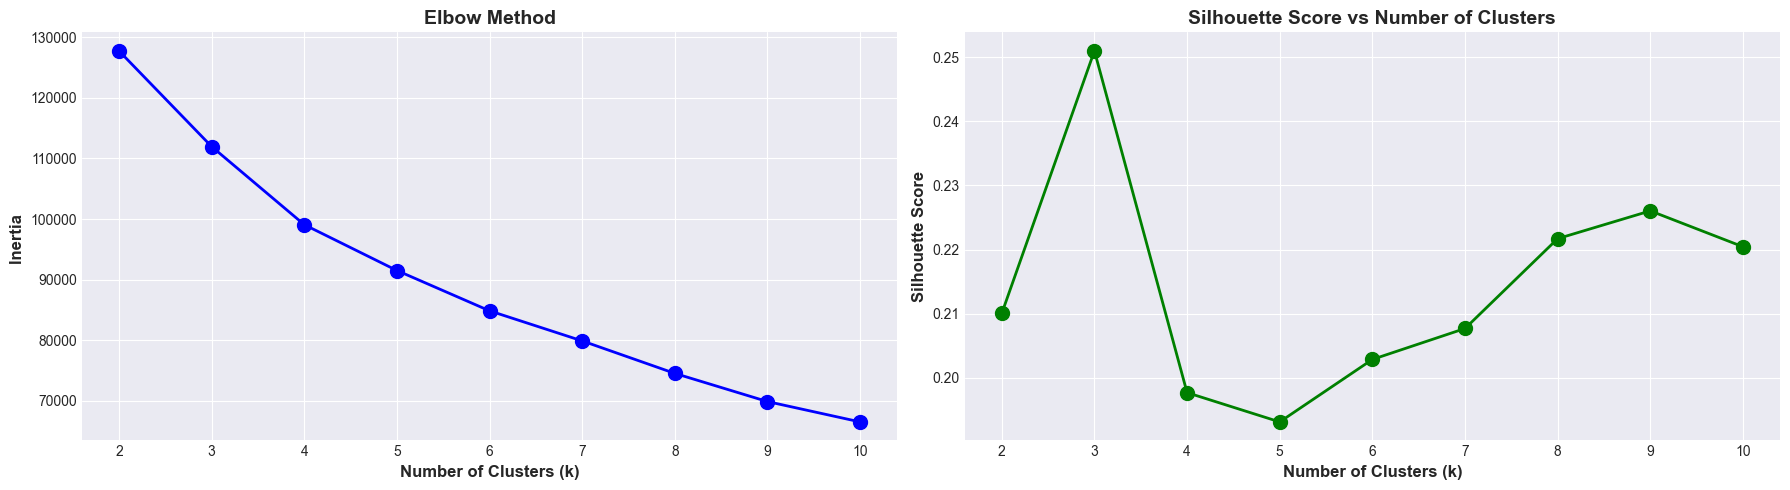

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=10)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inertia ', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xticks(K_range)

axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=10)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[1].set_title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
axes[1].set_xticks(K_range)


plt.tight_layout()
plt.show()

In [27]:
optimal_k_silhouette = K_range[np.argmax(silhouette_scores)]

print("Optimal Number of Clusters:")
print("="*80)
print(f"Based on Silhouette Score: k = {optimal_k_silhouette} (Score: {max(silhouette_scores):.3f})")


Optimal Number of Clusters:
Based on Silhouette Score: k = 3 (Score: 0.251)


In [28]:
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
cluster_labels = kmeans_final.fit_predict(df_scaled)

df_processed_imputed['Cluster'] = cluster_labels
df_scaled['Cluster'] = cluster_labels

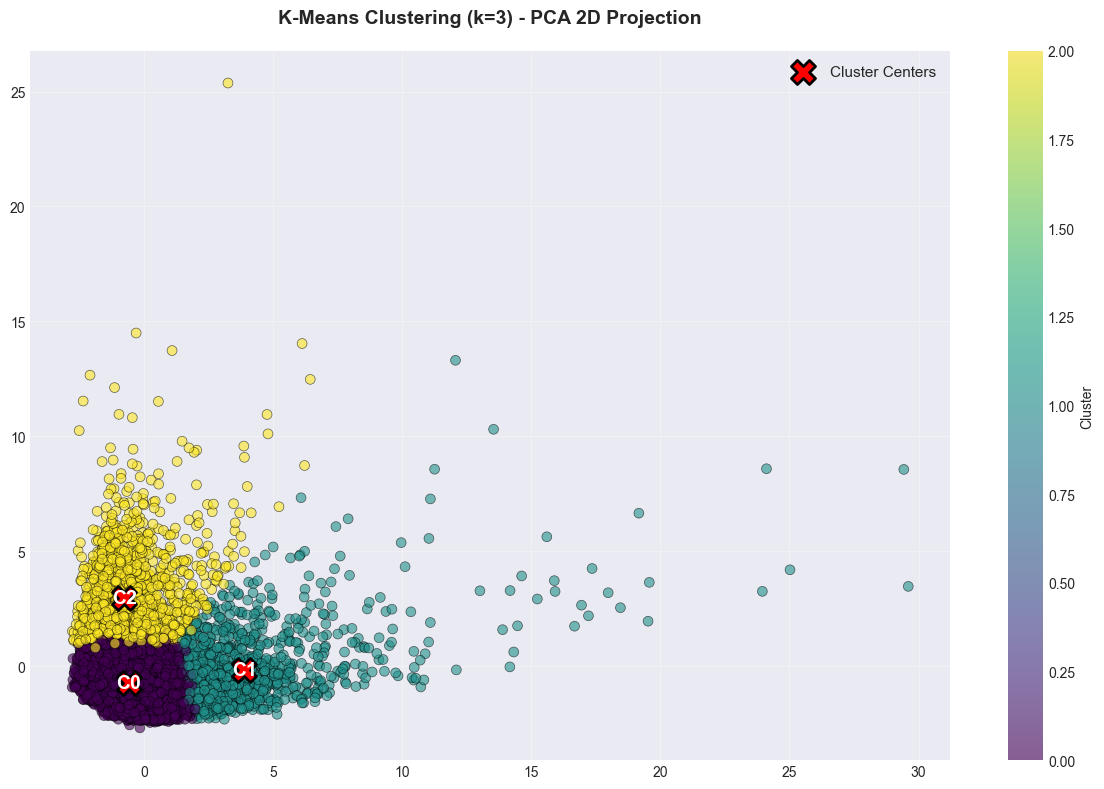

In [29]:
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(data_pca[:, 0], data_pca[:, 1],  c=cluster_labels, cmap='viridis', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
centers_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],  c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Cluster Centers')

for i, center in enumerate(centers_pca):
    ax.annotate(f'C{i}', center, fontsize=14, fontweight='bold', ha='center', va='center', color='white')

ax.set_title(f'K-Means Clustering (k={optimal_k}) - PCA 2D Projection', fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Cluster Analysis</div>


In [30]:
cluster_profiles = df_processed_imputed.groupby('Cluster').mean()
cluster_profiles

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,799.750669,0.835077,505.532394,253.120131,252.733061,330.817885,0.465072,0.132333,0.345145,0.068260,1.209675,8.653865,3271.510637,909.677092,523.213219,0.155750,11.479654
1,2220.003291,0.981477,4268.520980,2717.828543,1551.178267,458.421147,0.949093,0.668166,0.744584,0.063014,1.528745,56.472065,7733.967611,4151.276172,1220.516917,0.298632,11.923077
2,3989.142419,0.958403,384.528277,248.718133,135.887632,3866.210340,0.232290,0.110942,0.144242,0.447393,12.397870,5.612155,6675.441445,3019.108570,1787.616215,0.033774,11.347744


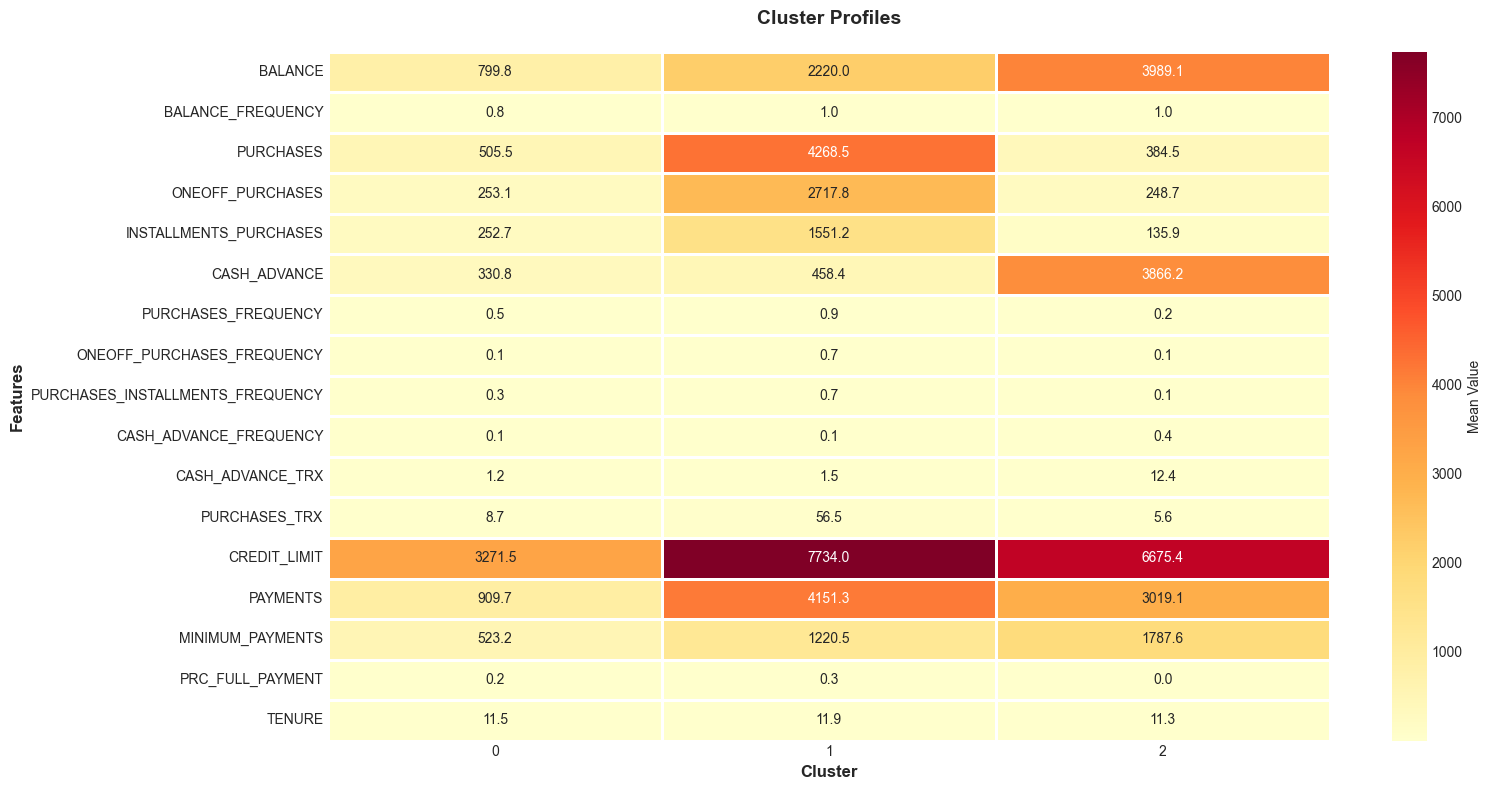

In [31]:
fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(cluster_profiles.T, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=1, cbar_kws={'label': 'Mean Value'}, ax=ax)
ax.set_xlabel('Cluster', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Cluster Profiles', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">Hierarchical Clustering</div>


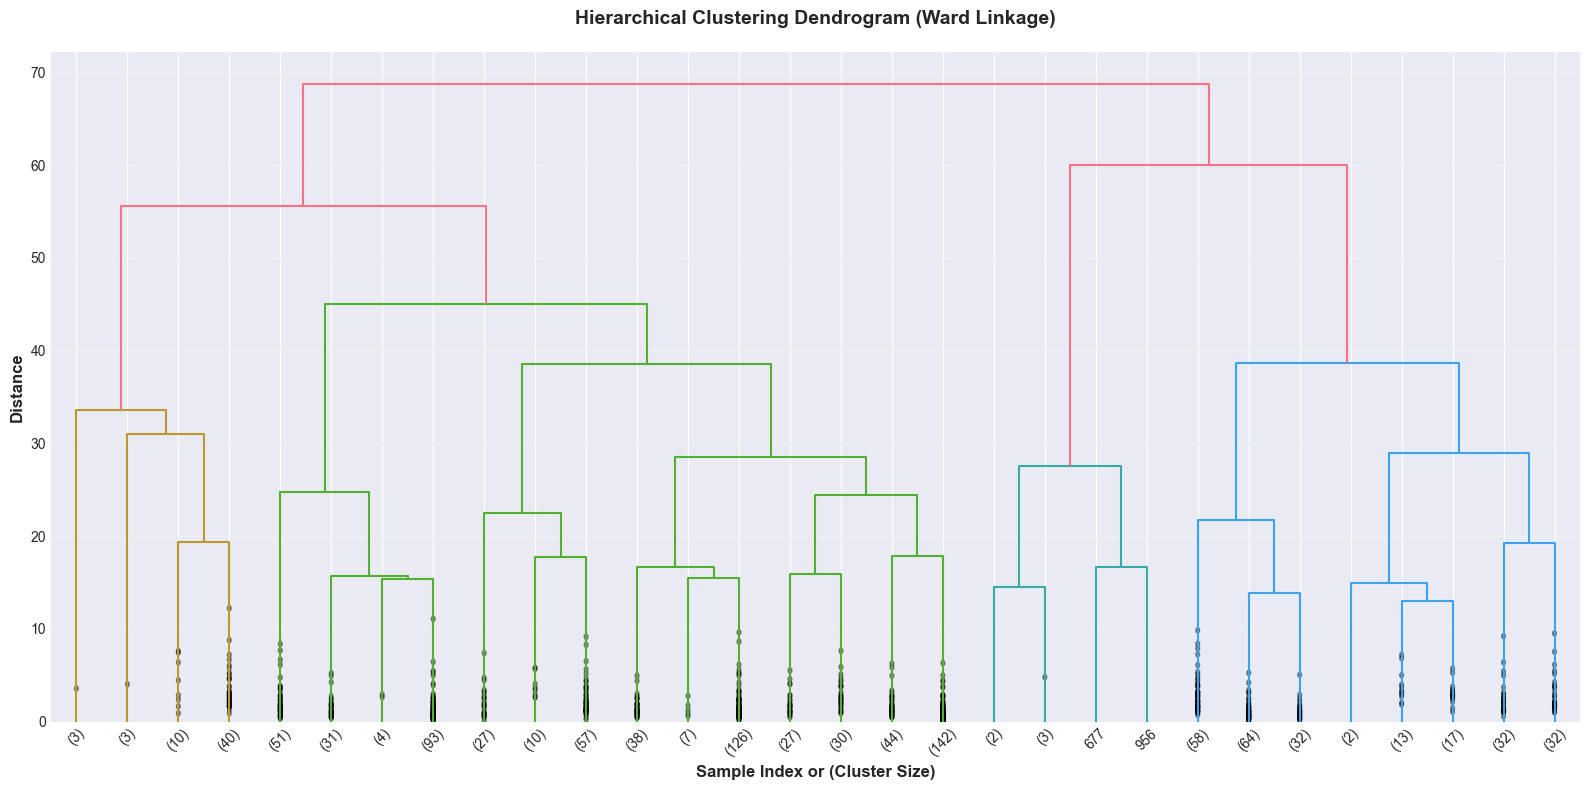

Dendrogram created using 1000 samples


In [32]:
sample_size = min(1000, len(df_scaled))
sample_indices = np.random.choice(len(df_scaled), sample_size, replace=False)
df_sample = df_scaled.drop('Cluster', axis=1).iloc[sample_indices]

linkage_matrix = linkage(df_sample, method='ward')

fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(linkage_matrix, ax=ax, truncate_mode='lastp', p=30, 
           leaf_font_size=10, show_contracted=True)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Sample Index or (Cluster Size)', fontsize=12, fontweight='bold')
ax.set_ylabel('Distance', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Dendrogram created using {sample_size} samples")

In [33]:
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(df_scaled.drop('Cluster', axis=1))

from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(cluster_labels, hierarchical_labels)

print(f"Hierarchical Clustering Results (k={optimal_k}):")
print("="*80)
print(f"Adjusted Rand Index (vs K-Means): {ari:.3f}")
print(f"\nCluster distribution:")
print(pd.Series(hierarchical_labels).value_counts().sort_index())

Hierarchical Clustering Results (k=3):
Adjusted Rand Index (vs K-Means): 0.355

Cluster distribution:
0    2881
1    4875
2    1194
Name: count, dtype: int64


<div style="text-align: center; background: #1ED760; font-family: 'Trebuchet MS', Arial, sans-serif; color: white; padding: 15px; font-size: 26px; font-weight: bold; line-height: 1; border-radius: 50% 0 50% 0 / 40px; margin-bottom: 20px; box-shadow: 0px 4px 6px rgba(0, 0, 0, 0.1);">DBSCAN</div>


In [34]:
dbscan = DBSCAN(eps=3, min_samples=50)
dbscan_labels = dbscan.fit_predict(df_scaled.drop('Cluster', axis=1))

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN Results (eps=3, min_samples=50):")
print("="*80)
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")
print(f"\nCluster distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN Results (eps=3, min_samples=50):
Number of clusters: 1
Number of noise points: 344 (3.8%)

Cluster distribution:
-1     344
 0    8606
Name: count, dtype: int64


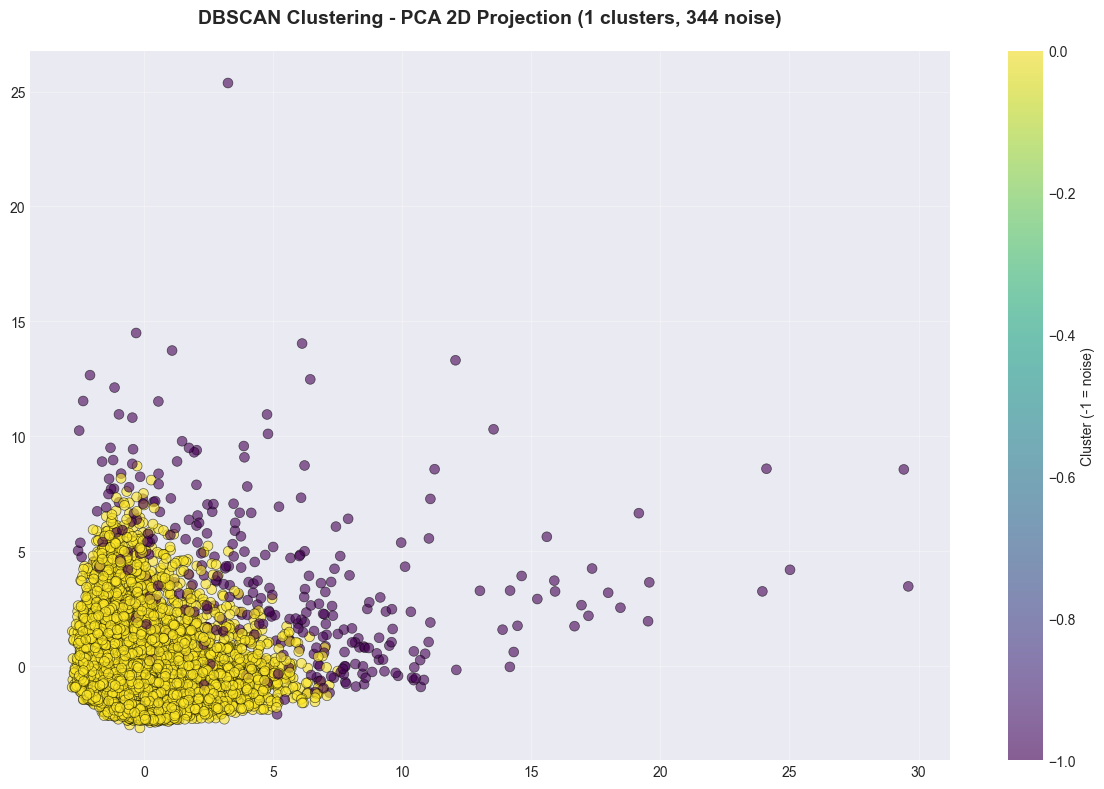

In [35]:
# Visualize DBSCAN results
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(data_pca[:, 0], data_pca[:, 1], 
                     c=dbscan_labels, cmap='viridis', 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax.set_title(f'DBSCAN Clustering - PCA 2D Projection ({n_clusters_dbscan} clusters, {n_noise} noise)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(alpha=0.3)

plt.colorbar(scatter, ax=ax, label='Cluster (-1 = noise)')
plt.tight_layout()
plt.show()